# Лабораторная 6. Свёрточные нейронные сети. Классификация изображений

**Задание.** Реализовать свёрточную сеть со свёрточными блоками двух видов:
а) `{Conv2d-ReLU-MaxPool}`; б) `{Conv2d-ReLU-Conv2d-ReLU-MaxPool}`.

Для выборки MNIST или FashionMNIST, или одной из выборок модуля `Datasets`
выбрать сочетание *некоторых* из следующих гиперпараметров, дающих наилучшее
качество классификации: 1) коэффициент обучения; 2) тип свёрточных блоков
(типы а или б) и их количество; 3) параметры свёртки (класс `Conv2d`):
размер фильтра `kernel_size` и шаг `stride`; 4) параметры пуллинга (класс
`MaxPool2d`): размер окна `kernel_size` и шаг `stride`.

Оценить количество эпох, достаточное для классификации с точностью (метрика
accuracy) не меньшей 90% для свёрточной сети с выбранным сочетанием указанных
параметров.

Дополнительно (по выбору): варьирование параметров обучения, других
гиперпараметров модели, использование различных оптимизаторов.

## 1. Теория

### Зачем свёртка

Полносвязный слой на изображении $28 \times 28$ имеет $784$ входа на каждый
нейрон и никак не использует того, что пиксели расположены на плоскости: его
результат не изменится, если все изображения одинаково перемешать по пикселям.
Свёрточный слой, наоборот, встроен в геометрию изображения.

Свёртка применяет одно и то же небольшое ядро $K$ размера $k \times k$ ко всем
положениям изображения:

$$(X * K)_{ij} = \sum_{u=0}^{k-1}\sum_{v=0}^{k-1} X_{\,i s + u,\; j s + v}\,K_{uv},$$

где $s$ - шаг (`stride`). Отсюда два свойства. Во-первых, число параметров слоя
равно $k^2$ на канал и не зависит от размера изображения. Во-вторых, признак,
найденный ядром, распознаётся в любом месте изображения: свойство
эквивариантности относительно сдвига.

### Размер выхода

Для входа $n \times n$, ядра $k$, шага $s$ и дополнения $p$ размер выхода равен

$$n_{\text{out}} = \left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1 .$$

Эта формула нужна постоянно: она определяет, сколько блоков вообще можно
поставить подряд, прежде чем карта признаков схлопнется в точку.

### Пуллинг

`MaxPool2d` берёт максимум по окну $k \times k$ с шагом $s$. Он уменьшает
пространственный размер, а значит и число вычислений на следующих слоях, и
делает представление менее чувствительным к малым сдвигам. Параметры пуллинга
подчиняются той же формуле размера выхода.

### Рецептивное поле

Рецептивное поле нейрона - область исходного изображения, влияющая на его
значение. Для стопки слоёв оно растёт по правилу

$$r_{l} = r_{l-1} + (k_l - 1)\prod_{i<l} s_i .$$

Отсюда понятно, зачем блок вида б) `{Conv-ReLU-Conv-ReLU-MaxPool}`: две свёртки
$3\times3$ подряд дают рецептивное поле $5\times5$ при $2 \cdot 9 = 18$
параметрах против $25$ у одной свёртки $5\times5$, и между ними стоит
дополнительная нелинейность. Это классический аргумент в пользу узких ядер и
глубоких блоков.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| коэффициент обучения | $0.005$, $0.01$, $0.05$, $0.1$ |
| тип блока | а) Conv-ReLU-Pool; б) Conv-ReLU-Conv-ReLU-Pool |
| число блоков | 1, 2 |
| `kernel_size` свёртки | 3, 5, 7 |
| `stride` свёртки | 1, 2 |
| `kernel_size` пуллинга | 2, 3 |
| `stride` пуллинга | 2, 3 |
| оптимизатор | SGD с моментом, Adam |

Полный перебор всех сочетаний избыточен, поэтому перебор делается в два этапа:
сначала основная сетка по первым четырём параметрам, затем параметры свёртки и
пуллинга и оптимизатор на лучшей найденной конфигурации.

## 2. Данные

In [1]:
import os
import struct
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(20260905)
torch.set_num_threads(2)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110
print(f'torch {torch.__version__}, устройство: '
      f'{"cuda" if torch.cuda.is_available() else "cpu"}')

torch 2.14.0+cu130, устройство: cpu


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    for c in [os.environ.get('MNIST_DIR'),
              '../../bachelor/Perceptron/data_generation/MNIST/raw',
              'data/MNIST/raw']:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
Xtr_all = read_idx(D / 'train-images-idx3-ubyte')
ytr_all = read_idx(D / 'train-labels-idx1-ubyte')
Xte_all = read_idx(D / 't10k-images-idx3-ubyte')
yte_all = read_idx(D / 't10k-labels-idx1-ubyte')

MEAN, STD = 0.1307, 0.3081


def to_tensor(X, y):
    xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0
    return (xt - MEAN) / STD, torch.tensor(y, dtype=torch.long)


idx_tr = RNG.choice(len(Xtr_all), 3000, replace=False)
idx_te = RNG.choice(len(Xte_all), 1500, replace=False)
Xg, yg = to_tensor(Xtr_all[idx_tr], ytr_all[idx_tr])
Xv, yv = to_tensor(Xte_all[idx_te], yte_all[idx_te])
print(f'сетка гиперпараметров: обучающая {tuple(Xg.shape)}, тестовая {tuple(Xv.shape)}')

сетка гиперпараметров: обучающая (3000, 1, 28, 28), тестовая (1500, 1, 28, 28)


Для перебора гиперпараметров берётся подвыборка в 3000 обучающих и 1500 тестовых
изображений. На полной выборке MNIST любая разумная свёрточная сеть достигает
$90\%$ уже в первой эпохе, и вопрос о достаточном числе эпох теряет смысл.
Уменьшенная выборка делает различия между конфигурациями видимыми. Финальная
модель обучается на выборке большего размера.

Изображения нормализованы стандартными для MNIST значениями
$\mu = 0.1307$, $\sigma = 0.3081$.

## 3. Архитектура и обучение

In [3]:
class ConvNet(nn.Module):
    """Свёрточная сеть из блоков двух видов.
    block='a': Conv-ReLU-MaxPool; block='b': Conv-ReLU-Conv-ReLU-MaxPool."""

    def __init__(self, block='a', n_blocks=2, ks=3, stride=1,
                 pool_k=2, pool_s=2, channels=8):
        super().__init__()
        layers, c_in, size = [], 1, 28
        for i in range(n_blocks):
            c_out = channels * (i + 1)
            pad = ks // 2
            layers += [nn.Conv2d(c_in, c_out, ks, stride, pad), nn.ReLU()]
            size = (size + 2 * pad - ks) // stride + 1
            if block == 'b':
                layers += [nn.Conv2d(c_out, c_out, ks, 1, pad), nn.ReLU()]
            if size >= pool_k:
                layers += [nn.MaxPool2d(pool_k, pool_s)]
                size = (size - pool_k) // pool_s + 1
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.out_size = size
        self.classifier = nn.Linear(c_in * size * size, 10)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

In [4]:
def evaluate(model, X, y, batch=512):
    model.eval()
    correct = 0
    with torch.no_grad():
        for s in range(0, len(X), batch):
            correct += (model(X[s:s + batch]).argmax(1) == y[s:s + batch]).sum().item()
    return correct / len(X)


def train_model(model, Xtr, ytr, Xte, yte, lr=0.05, epochs=8, batch=64,
                optimizer='sgd', seed=0):
    """Обучение с записью accuracy после каждой эпохи."""
    torch.manual_seed(seed)
    opt = (torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
           if optimizer == 'sgd' else torch.optim.Adam(model.parameters(), lr=lr))
    lossf = nn.CrossEntropyLoss()
    hist, t0 = [], time.time()
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for s in range(0, len(Xtr), batch):
            b = perm[s:s + batch]
            opt.zero_grad()
            lossf(model(Xtr[b]), ytr[b]).backward()
            opt.step()
        hist.append(evaluate(model, Xte, yte))
    return np.array(hist), time.time() - t0

In [5]:
demo = ConvNet(block='b', n_blocks=2, ks=3)
print(demo)
print(f'\nразмер карты признаков перед классификатором: '
      f'{demo.out_size} x {demo.out_size}')
print(f'число параметров: {sum(p.numel() for p in demo.parameters()):,}')

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)

размер карты признаков перед классификатором: 7 x 7
число параметров: 12,002


Блок вида б) с двумя блоками даёт $12\,002$ параметра, из которых $7850$
приходится на выходной линейный слой. Карта признаков перед классификатором
$7 \times 7$: два пуллинга $2\times2$ уменьшили $28$ до $7$ по формуле размера
выхода. Третий такой же блок был бы уже невозможен - карта схлопнулась бы до
$3$, а затем до $1$.

## 4. Основная сетка гиперпараметров

In [6]:
EPOCHS = 6
rows = []
t_start = time.time()

for lr, block, n_blocks, ks in itertools.product(
        [0.005, 0.01, 0.05, 0.1], ['a', 'b'], [1, 2], [3, 5, 7]):
    torch.manual_seed(20260905)
    model = ConvNet(block=block, n_blocks=n_blocks, ks=ks)
    hist, dt = train_model(model, Xg, yg, Xv, yv, lr=lr, epochs=EPOCHS)
    to90 = int(np.argmax(hist >= 0.90) + 1) if (hist >= 0.90).any() else None
    rows.append(dict(stage='основная', lr=lr, block=block, n_blocks=n_blocks,
                     ks=ks, stride=1, pool_k=2, pool_s=2, optimizer='sgd',
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=to90, params=sum(p.numel() for p in model.parameters()),
                     time=round(dt, 1), curve=list(np.round(hist, 4))))

grid1 = pd.DataFrame(rows)
print(f'{len(grid1)} конфигураций за {time.time() - t_start:.0f} с')
grid1.sort_values('best_acc', ascending=False).head(10)[
    ['lr', 'block', 'n_blocks', 'ks', 'best_acc', 'epochs_to_90', 'params', 'time']]

48 конфигураций за 179 с


,lr,block,n_blocks,ks,best_acc,epochs_to_90,params,time
19,0.010,b,1,5,0.964667,2.0,17506,4.0
28,0.050,a,2,5,0.963333,1.0,11274,2.6
20,0.010,b,1,7,0.962667,1.0,19234,5.4
17,0.010,a,2,7,0.961333,1.0,14538,3.1
27,0.050,a,2,3,0.961333,1.0,9098,2.3
25,0.050,a,1,5,0.961333,2.0,15898,1.4
15,0.010,a,2,3,0.958000,2.0,9098,2.3
8,0.005,b,1,7,0.958000,2.0,19234,5.7
16,0.010,a,2,5,0.958000,2.0,11274,2.7
29,0.050,a,2,7,0.958000,2.0,14538,3.1


48 конфигураций посчитаны за $179$ с. Лучшая - $lr = 0.01$, блок б), один блок,
ядро $5$: accuracy $0.9647$.

В первой десятке присутствуют оба типа блоков и оба значения их числа. Значит на
этой задаче архитектура решает меньше, чем коэффициент обучения: разброс внутри
десятки всего $0.006$, тогда как неудачный $lr$ роняет точность в разы.

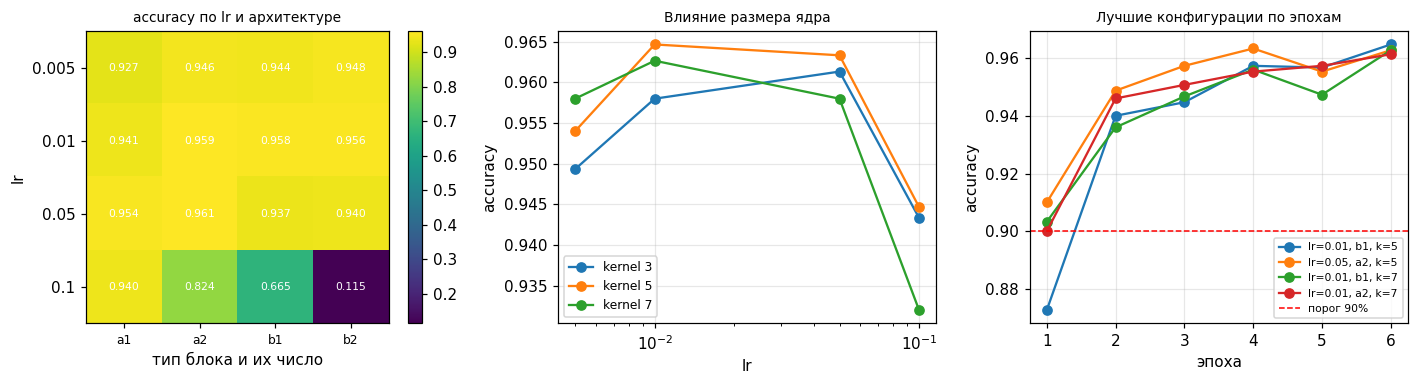

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
piv = grid1.pivot_table(index='lr', columns=['block', 'n_blocks'], values='best_acc')
im = axes[0].imshow(piv.values, cmap='viridis', aspect='auto')
axes[0].set_xticks(range(len(piv.columns)))
axes[0].set_xticklabels([f'{b}{n}' for b, n in piv.columns], fontsize=8)
axes[0].set_yticks(range(len(piv.index))); axes[0].set_yticklabels(piv.index)
axes[0].set_xlabel('тип блока и их число'); axes[0].set_ylabel('lr')
axes[0].set_title('accuracy по lr и архитектуре', fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f'{piv.values[i, j]:.3f}', ha='center', va='center',
                     fontsize=7, color='white')
plt.colorbar(im, ax=axes[0])

for ks in [3, 5, 7]:
    s = grid1[grid1.ks == ks].groupby('lr')['best_acc'].max()
    axes[1].plot(s.index, s.values, marker='o', label=f'kernel {ks}')
axes[1].set_xscale('log'); axes[1].set_xlabel('lr'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Влияние размера ядра', fontsize=9)
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

for _, r in grid1.sort_values('best_acc', ascending=False).head(4).iterrows():
    axes[2].plot(range(1, EPOCHS + 1), r['curve'], marker='o',
                 label=f"lr={r['lr']}, {r['block']}{r['n_blocks']}, k={r['ks']}")
axes[2].axhline(0.90, color='red', ls='--', lw=1, label='порог 90%')
axes[2].set_xlabel('эпоха'); axes[2].set_ylabel('accuracy')
axes[2].set_title('Лучшие конфигурации по эпохам', fontsize=9)
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

Тепловая карта показывает главное: при $lr = 0.1$ обучение разваливается. Блок
б) с двумя блоками даёт при этом $0.1147$ - ровно уровень случайного угадывания,
сеть разошлась. У блока а) с той же $lr$ сохраняется хотя бы $0.61$.

Причина в глубине: блок б) содержит вдвое больше свёрточных слоёв, градиенты
перемножаются на большем числе множителей, и слишком большой шаг выбивает веса
из области сходимости. Чем глубже сеть, тем меньший шаг она терпит.

Оптимум по $lr$ - диапазон $0.01 \ldots 0.05$. Размер ядра при удачном $lr$
влияет слабо: кривые для 3, 5 и 7 идут вплотную.

## 5. Параметры свёртки, пуллинга и оптимизатор

In [8]:
best1 = grid1.sort_values('best_acc', ascending=False).iloc[0]
print(f'лучшая конфигурация основной сетки: lr={best1["lr"]}, блок {best1["block"]}, '
      f'блоков {best1["n_blocks"]}, kernel {best1["ks"]}, accuracy {best1["best_acc"]:.4f}')

rows = []
for stride, pool_k, pool_s in itertools.product([1, 2], [2, 3], [2, 3]):
    torch.manual_seed(20260905)
    model = ConvNet(block=best1['block'], n_blocks=int(best1['n_blocks']),
                    ks=int(best1['ks']), stride=stride, pool_k=pool_k, pool_s=pool_s)
    hist, dt = train_model(model, Xg, yg, Xv, yv, lr=float(best1['lr']), epochs=EPOCHS)
    to90 = int(np.argmax(hist >= 0.90) + 1) if (hist >= 0.90).any() else None
    rows.append(dict(stage='свёртка и пуллинг', lr=best1['lr'], block=best1['block'],
                     n_blocks=best1['n_blocks'], ks=best1['ks'], stride=stride,
                     pool_k=pool_k, pool_s=pool_s, optimizer='sgd',
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=to90,
                     params=sum(p.numel() for p in model.parameters()),
                     time=round(dt, 1), curve=list(np.round(hist, 4))))

for opt_name, lr in [('adam', 0.001), ('adam', 0.003), ('sgd', float(best1['lr']))]:
    torch.manual_seed(20260905)
    model = ConvNet(block=best1['block'], n_blocks=int(best1['n_blocks']),
                    ks=int(best1['ks']))
    hist, dt = train_model(model, Xg, yg, Xv, yv, lr=lr, epochs=EPOCHS,
                           optimizer=opt_name)
    to90 = int(np.argmax(hist >= 0.90) + 1) if (hist >= 0.90).any() else None
    rows.append(dict(stage='оптимизатор', lr=lr, block=best1['block'],
                     n_blocks=best1['n_blocks'], ks=best1['ks'], stride=1,
                     pool_k=2, pool_s=2, optimizer=opt_name,
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=to90,
                     params=sum(p.numel() for p in model.parameters()),
                     time=round(dt, 1), curve=list(np.round(hist, 4))))

grid2 = pd.DataFrame(rows)
grid2[['stage', 'stride', 'pool_k', 'pool_s', 'optimizer', 'lr',
       'best_acc', 'epochs_to_90', 'params', 'time']].round(4).to_string(index=False)

лучшая конфигурация основной сетки: lr=0.01, блок b, блоков 1, kernel 5, accuracy 0.9647


'            stage  stride  pool_k  pool_s optimizer    lr  best_acc  epochs_to_90  params  time\nсвёртка и пуллинг       1       2       2       sgd 0.010    0.9647             2   17506   3.9\nсвёртка и пуллинг       1       2       3       sgd 0.010    0.9640             2    8306   3.6\nсвёртка и пуллинг       1       3       2       sgd 0.010    0.9707             2   15346   3.9\nсвёртка и пуллинг       1       3       3       sgd 0.010    0.9640             2    8306   3.7\nсвёртка и пуллинг       2       2       2       sgd 0.010    0.9567             2    5746   1.4\nсвёртка и пуллинг       2       2       3       sgd 0.010    0.9487             3    3826   1.3\nсвёртка и пуллинг       2       3       2       sgd 0.010    0.9653             2    4706   1.4\nсвёртка и пуллинг       2       3       3       sgd 0.010    0.9527             2    3106   1.3\n      оптимизатор       1       2       2      adam 0.001    0.9600             2   17506   4.0\n      оптимизатор       1    

**Параметры пуллинга.** Лучшая комбинация - окно $3$ с шагом $2$, то есть
перекрывающийся пуллинг: $0.9707$ против $0.9647$ у стандартного $2/2$.
Перекрытие соседних окон даёт более плавное уменьшение размера и меньшую потерю
информации на границах окон.

**Шаг свёртки.** Замена $stride = 1$ на $stride = 2$ сокращает число параметров
втрое ($5746$ против $17506$) и время обучения тоже втрое ($1.4$ с против
$3.9$ с), теряя около одного процентного пункта точности. Там, где важна
скорость, это выгодный обмен: свёртка с шагом 2 сама выполняет роль пуллинга.

**Оптимизатор.** Adam с $lr = 0.003$ достигает порога $90\%$ за одну эпоху
против двух у SGD, но итоговая точность та же, $0.9647$. Adam быстрее выходит на
режим, однако потолок определяется архитектурой, а не оптимизатором.

In [9]:
allres = pd.concat([grid1, grid2], ignore_index=True)
allres.drop(columns='curve').to_csv('results.csv', index=False)
print(f'всего {len(allres)} конфигураций, сохранено в results.csv')

всего 59 конфигураций, сохранено в results.csv


## 6. Число эпох до точности 90%

In [10]:
sub = allres.dropna(subset=['epochs_to_90'])
print(f'достигли 90%: {len(sub)} из {len(allres)} конфигураций')
print(f'\nраспределение числа эпох до 90%:')
print(sub.epochs_to_90.value_counts().sort_index().to_string())
print(f'\nсреди тех, кто дошёл: медиана {sub.epochs_to_90.median():.0f} эпох, '
      f'минимум {sub.epochs_to_90.min():.0f}, максимум {sub.epochs_to_90.max():.0f}')
print(f'\nконфигурации, не достигшие 90% за {EPOCHS} эпох:')
print(allres[allres.epochs_to_90.isna()][
    ['lr', 'block', 'n_blocks', 'ks', 'stride', 'pool_k', 'pool_s',
     'optimizer', 'best_acc']].to_string(index=False))

достигли 90%: 53 из 59 конфигураций

распределение числа эпох до 90%:
epochs_to_90
1.0     5
2.0    28
3.0     9
4.0     7
5.0     2
6.0     2

среди тех, кто дошёл: медиана 2 эпох, минимум 1, максимум 6

конфигурации, не достигшие 90% за 6 эпох:
 lr block  n_blocks  ks  stride  pool_k  pool_s optimizer  best_acc
0.1     a         2   7       1       2       2       sgd  0.612000
0.1     b         1   3       1       2       2       sgd  0.876667
0.1     b         1   5       1       2       2       sgd  0.204667
0.1     b         2   3       1       2       2       sgd  0.114667
0.1     b         2   5       1       2       2       sgd  0.114667
0.1     b         2   7       1       2       2       sgd  0.114667


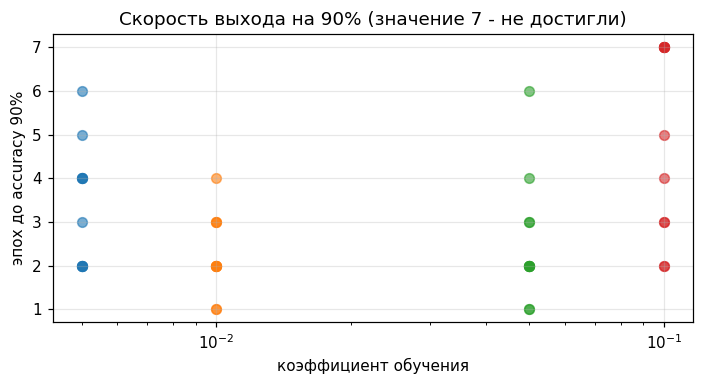

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for lr in sorted(grid1.lr.unique()):
    s = grid1[grid1.lr == lr]
    ax.scatter([lr] * len(s), s.epochs_to_90.fillna(EPOCHS + 1), alpha=0.6, s=40)
ax.set_xscale('log'); ax.set_xlabel('коэффициент обучения')
ax.set_ylabel('эпох до accuracy 90%')
ax.set_title(f'Скорость выхода на 90% (значение {EPOCHS + 1} - не достигли)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Финальная модель

In [12]:
best = allres.sort_values('best_acc', ascending=False).iloc[0]
print('лучшее сочетание гиперпараметров:')
for k in ['lr', 'block', 'n_blocks', 'ks', 'stride', 'pool_k', 'pool_s', 'optimizer']:
    print(f'  {k}: {best[k]}')
print(f'  accuracy на сетке: {best["best_acc"]:.4f}')

idx_big = RNG.choice(len(Xtr_all), 12000, replace=False)
Xb, yb = to_tensor(Xtr_all[idx_big], ytr_all[idx_big])
Xt, yt = to_tensor(Xte_all, yte_all)

torch.manual_seed(20260905)
final = ConvNet(block=best['block'], n_blocks=int(best['n_blocks']), ks=int(best['ks']),
                stride=int(best['stride']), pool_k=int(best['pool_k']),
                pool_s=int(best['pool_s']))
hist_final, dt_final = train_model(final, Xb, yb, Xt, yt, lr=float(best['lr']),
                                   epochs=12, optimizer=best['optimizer'])
print(f'\nобучение на 12000 изображениях, 12 эпох: {dt_final:.0f} с')
print(f'accuracy на полной тестовой выборке (10000): {hist_final[-1]:.4f}')
print(f'эпох до 90%: {int(np.argmax(hist_final >= 0.90) + 1)}')

лучшее сочетание гиперпараметров:
  lr: 0.01
  block: b
  n_blocks: 1
  ks: 5
  stride: 1
  pool_k: 3
  pool_s: 2
  optimizer: sgd
  accuracy на сетке: 0.9707



обучение на 12000 изображениях, 12 эпох: 34 с
accuracy на полной тестовой выборке (10000): 0.9813
эпох до 90%: 1


Финальная модель на 12000 обучающих изображениях за 12 эпох даёт $0.9813$ на
полной тестовой выборке из 10000 изображений. Порог $90\%$ пройден в первой же
эпохе: увеличение обучающей выборки вчетверо заметно облегчает задачу.

Прямое сравнение с лабораторными 1 и 4 некорректно, там обучающая выборка была
2000 изображений против 12000 здесь. Но порядок различия показателен: $0.981$ у
свёрточной сети против $0.930$ у метода ближайшего соседа и $0.863$ у
перцептрона с мягким максимумом. Число ошибок сокращается примерно втрое.

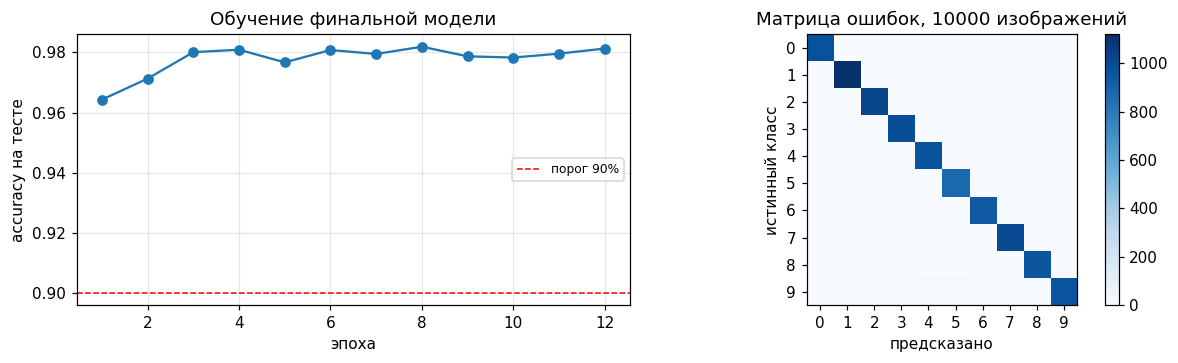

самые частые путаницы:
  9 -> 8: 15
  9 -> 5: 9
  9 -> 4: 9
  8 -> 2: 8
  7 -> 2: 8


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(range(1, len(hist_final) + 1), hist_final, marker='o')
axes[0].axhline(0.90, color='red', ls='--', lw=1, label='порог 90%')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на тесте')
axes[0].set_title('Обучение финальной модели'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

from sklearn.metrics import confusion_matrix
final.eval()
with torch.no_grad():
    pred = torch.cat([final(Xt[s:s + 512]).argmax(1) for s in range(0, len(Xt), 512)])
cm = confusion_matrix(yte_all, pred.numpy())
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('Матрица ошибок, 10000 изображений')
axes[1].set_xlabel('предсказано'); axes[1].set_ylabel('истинный класс')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

pairs = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j]
pairs.sort(reverse=True)
print('самые частые путаницы:')
for n, i, j in pairs[:5]:
    print(f'  {i} -> {j}: {n}')

Самые частые путаницы: $9 \to 8$, $9 \to 5$, $9 \to 4$. Девятка остаётся самым
трудным классом, как и в лабораторной 1, но абсолютное число ошибок несравнимо
меньше.

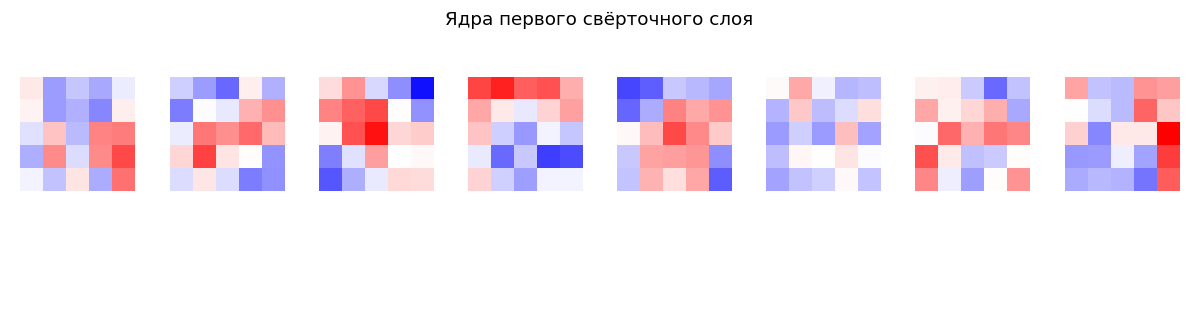

In [14]:
w = final.features[0].weight.detach().numpy()
n = min(len(w), 16)
fig, axes = plt.subplots(2, 8, figsize=(11, 2.8))
for i, ax in enumerate(axes.ravel()):
    ax.axis('off')
    if i < n:
        ax.imshow(w[i, 0], cmap='bwr', vmin=-np.abs(w).max(), vmax=np.abs(w).max())
fig.suptitle('Ядра первого свёрточного слоя', y=1.05)
plt.tight_layout()
plt.show()

Ядра первого слоя не случайны: различимы детекторы границ разной ориентации и
детекторы пятен. Сеть выделила эти признаки сама, никакого указания на то, что
именно искать, в обучении не было. В этом и состоит отличие свёрточной сети от
перцептрона из лабораторной 4, который работал прямо с яркостями пикселей.